In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.optimizers import Adam


In [2]:
def load_path(path):
    dataset = []
    for folder in os.listdir(path):
        folder = path + '/' + str(folder)
        if os.path.isdir(folder):
            for body in os.listdir(folder):
                path_p = folder + '/' + str(body)
                for id_p in os.listdir(path_p):
                    path_id = path_p + '/' + str(id_p)
                    for lab in os.listdir(path_id):
                        path_l = path_id + '/' + str(lab)
                        for img in os.listdir(path_l):
                            img_path = path_l + '/' + str(img)
                            dataset.append(
                                {
                                    'label': body,
                                    'image_path': img_path
                                }
                            )
    return dataset


In [3]:
import os
try:
    THIS_FOLDER = os.path.dirname(os.path.abspath(__file__))
except NameError:
    THIS_FOLDER = os.getcwd()
image_dir = THIS_FOLDER + '/Dataset'
data = load_path(image_dir)

labels = []
filepaths = []

Labels = ["Elbow", "Hand", "Shoulder"]

for row in data:
    labels.append(row['label'])
    filepaths.append(row['image_path'])

filepaths = pd.Series(filepaths, name='Filepath').astype(str)
labels = pd.Series(labels, name='Label')

images = pd.concat([filepaths, labels], axis=1)

In [4]:
train_df, test_df = train_test_split(
    images, train_size=0.9, shuffle=True, random_state=1
)

In [5]:
train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
    validation_split=0.2
)
test_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)

In [6]:
train_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=64,
    shuffle=True,
    seed=42,
    subset='training'
)
val_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=64,
    shuffle=True,
    seed=42,
    subset='validation'
)
test_images = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

Found 14641 validated image filenames belonging to 3 classes.
Found 3660 validated image filenames belonging to 3 classes.
Found 2034 validated image filenames belonging to 3 classes.


In [7]:
base_model = tf.keras.applications.EfficientNetB1(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)
base_model.trainable = False

In [8]:
inputs = base_model.input
x = tf.keras.layers.Dense(128, activation='relu')(base_model.output)
x = tf.keras.layers.Dense(64, activation='relu')(x)
outputs = tf.keras.layers.Dense(len(Labels), activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)

In [9]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
callbacks = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    
    restore_best_weights=True
)
history = model.fit(
    train_images,
    validation_data=val_images,
    epochs=5,
    callbacks=[callbacks]
)

Epoch 1/5


C:\Users\lenovo\AppData\Roaming\Python\Python310\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


229/229 ━━━━━━━━━━━━━━━━━━━━ 1292s 5s/step - accuracy: 0.8306 - loss: 0.4923 - val_accuracy: 0.9877 - val_loss: 0.0506
Epoch 2/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 3599s 16s/step - accuracy: 0.9860 - loss: 0.0511 - val_accuracy: 0.9910 - val_loss: 0.0317
Epoch 3/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 937s 4s/step - accuracy: 0.9909 - loss: 0.0340 - val_accuracy: 0.9926 - val_loss: 0.0253
Epoch 4/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 916s 4s/step - accuracy: 0.9933 - loss: 0.0246 - val_accuracy: 0.9937 - val_loss: 0.0221
Epoch 5/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 875s 4s/step - accuracy: 0.9947 - loss: 0.0195 - val_accuracy: 0.9932 - val_loss: 0.0203


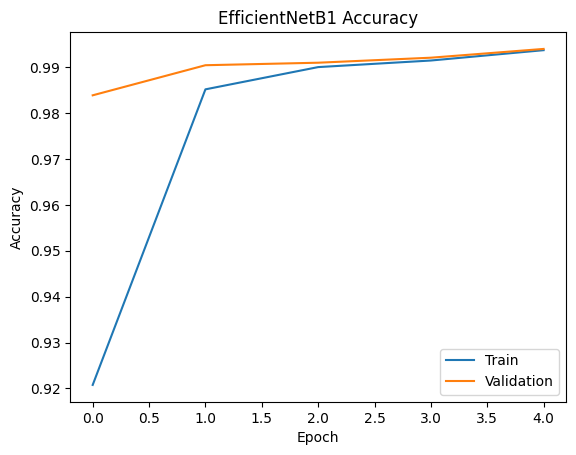

In [12]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('EfficientNetB1 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()


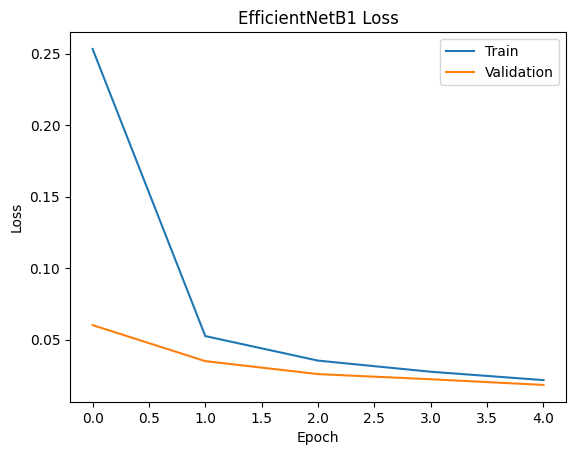

In [13]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('EfficientNetB1 Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

In [14]:
import numpy as np
from sklearn.metrics import classification_report
# Predict on test data
y_pred_probs = model.predict(test_images)
y_pred = np.argmax(y_pred_probs, axis=1)
# True labels
y_true = test_images.classes
# Class names (VERY IMPORTANT)
class_names = list(test_images.class_indices.keys())
# Classification report
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

64/64 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step 
              precision    recall  f1-score   support

       Elbow       0.98      0.99      0.99       527
        Hand       1.00      1.00      1.00       604
    Shoulder       0.99      0.99      0.99       903

    accuracy                           0.99      2034
   macro avg       0.99      0.99      0.99      2034
weighted avg       0.99      0.99      0.99      2034



<Figure size 600x600 with 0 Axes>

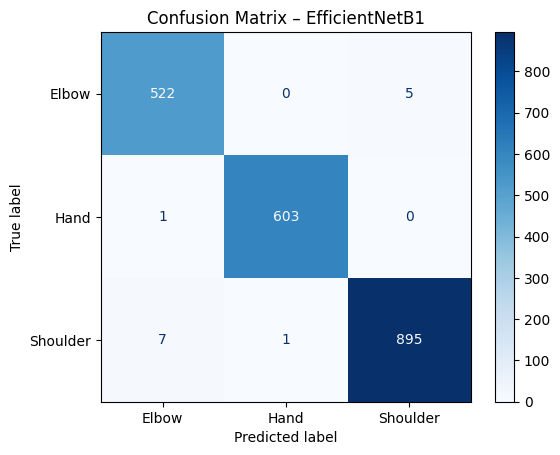

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_true, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

plt.figure(figsize=(6, 6))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix – EfficientNetB1")
plt.show()

In [16]:
model.save(os.path.join(THIS_FOLDER, 'weights/EfficientNetB1_BodyParts.h5'))